# MSDatasets Dataloader Example

This notebook demonstrates how to load the [`chrisagrams/consensus-100M-mszx`](https://huggingface.co/datasets/chrisagrams/consensus-100M-mszx) dataset using the [`msdatasets`](https://chrisagrams.github.io/msdatasets/) library, including PSM annotations, and shows how to inspect an example spectrum.

The full dataset is ~140 GB (90 shards of ~1.5 GB each). For a quick start, this notebook downloads only the **first shard** (`consensus_00.mszx`). The end of the notebook shows how to download the full dataset.

Run from the project root with:

```bash
uv run jupyter lab notebooks/dataloader_example.ipynb
```

## 1. Imports

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from msdatasets import load_hf_dataset
from mscompress.types import AnnotationFormat

## 2. Load the first shard with annotations

Passing `filenames=["consensus_00.mszx"]` restricts the download to a single shard (forwarded to `huggingface_hub.snapshot_download` as an allow-pattern). Annotations embedded in the `.mszx` shard are loaded via `load_annotations`; here we request Percolator TSV PSMs.

In [7]:
dataset = load_hf_dataset(
    "chrisagrams/consensus-100M-mszx",
    filenames=["consensus_00.mszx"],
    load_annotations=[
        AnnotationFormat.PERCOLATOR_TSV
    ],
)

print(f"Loaded {len(dataset):,} spectra from consensus_00.mszx")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 1,218,734 spectra from consensus_00.mszx


## 3. Inspect an example spectrum

When `load_annotations` is provided, `dataset[i]` yields `(mz, intensity, annotations)` where `mz` and `intensity` are 1-D `torch.Tensor`s and `annotations` is a `dict` keyed by `AnnotationFormat`.

In [8]:
INDEX = 0

mz, intensity, annotations = dataset[INDEX]

mz_np = mz.numpy()
intensity_np = intensity.numpy()

print(f"Spectrum {INDEX}:")
print(f"  peaks:           {len(mz_np):,}")
print(f"  m/z range:       {mz_np.min():.4f} - {mz_np.max():.4f}")
print(f"  intensity range: {intensity_np.min():.2f} - {intensity_np.max():.2f}")
print(f"  base peak m/z:   {mz_np[intensity_np.argmax()]:.4f}")
print(f"  annotation formats present: {[fmt.value for fmt in annotations]}")

Spectrum 0:
  peaks:           198
  m/z range:       101.0717 - 1190.5541
  intensity range: 272.39 - 44141.60
  base peak m/z:   129.1025
  annotation formats present: ['percolator_tsv']


## 4. Plot the spectrum

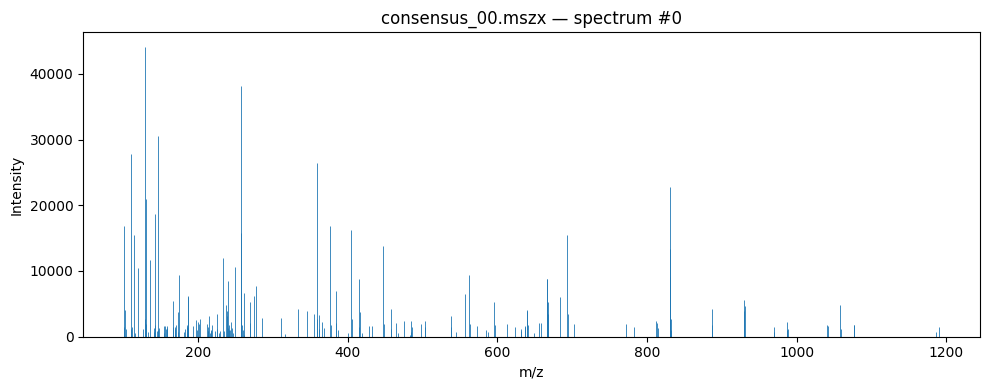

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.vlines(mz_np, 0, intensity_np, linewidth=0.6)
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title(f"consensus_00.mszx — spectrum #{INDEX}")
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

## 5. Inspect annotations

Each value in `annotations` is a list of PSM records for the spectrum in the requested format. Some spectra may have no PSMs in a given format.

In [10]:
for fmt, records in annotations.items():
    print(f"{fmt.value}: {len(records)} record(s)")
    if records:
        print(f"  example: {records[0]}")

percolator_tsv: 1 record(s)
  example: PSM(scan=1, peptide='AANFVHMDTAQK', charge=2, score=-1.0000)


## 6. Downloading the full dataset

To pull all 90 shards (~140 GB), drop `filenames` so every `*.mszx` is fetched. The cell below is left unevaluated — uncomment to run.

```python
full_dataset = load_hf_dataset(
    "chrisagrams/consensus-100M-mszx",
    load_annotations=[AnnotationFormat.PERCOLATOR_TSV],
)
print(f"Full dataset: {len(full_dataset):,} spectra across all shards")
```

Useful options on `load_hf_dataset`:

- `output_dir=Path("./data")` — download to a specific directory instead of the shared HF cache.
- `revision="main"` — pin a branch, tag, or commit.
- `token="hf_…"` — pass an auth token (also read from `HF_TOKEN`).
- `force_download=True` — re-download even if cached.
- `show_progress=False` — silence the progress bars.